# EXPLORATORY DATA ANALYSIS ON A DATASET

**Objective:**

The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.

**Dataset:**
1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
3.	FM - May indicate "Fetal Movements" detected by the monitor.
4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


***1.	Data Cleaning and Preparation:***

●	Load the dataset into a data frame or equivalent data structure.

●	Handle missing values appropriately (e.g., imputation, deletion).

●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).

●	Detect and treat outliers if necessary.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv(r"C:\Users\gowra\Downloads\Cardiotocographic.csv")

In [4]:
df = pd.DataFrame(data)

In [5]:
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [6]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [7]:
df.duplicated().sum()

2

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

0

In [10]:
df.fillna(df.mean(), inplace=True)

In [11]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2124 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2124 non-null   float64
 1   AC        2124 non-null   float64
 2   FM        2124 non-null   float64
 3   UC        2124 non-null   float64
 4   DL        2124 non-null   float64
 5   DS        2124 non-null   float64
 6   DP        2124 non-null   float64
 7   ASTV      2124 non-null   float64
 8   MSTV      2124 non-null   float64
 9   ALTV      2124 non-null   float64
 10  MLTV      2124 non-null   float64
 11  Width     2124 non-null   float64
 12  Tendency  2124 non-null   float64
 13  NSP       2124 non-null   float64
dtypes: float64(14)
memory usage: 248.9 KB


In [13]:
df['NSP'].value_counts()

NSP
 1.000000    1544
 2.000000     280
 3.000000     164
 1.304797      21
-1.000000       5
             ... 
 0.992847       1
 2.971309       1
 0.984834       1
 0.991200       1
 1.990464       1
Name: count, Length: 112, dtype: int64

In [14]:
z_scores = np.abs((df - df.mean()) / df.std())
outlier_threshold = 3
#outliers
outliers = df[z_scores > outlier_threshold].dropna(how='all')
print(outliers)

      LB        AC        FM  UC  DL        DS        DP  ASTV  MSTV  ALTV  \
5    NaN       NaN       NaN NaN NaN       NaN       NaN   NaN   5.9   NaN   
6    NaN       NaN       NaN NaN NaN       NaN  0.002805   NaN   6.3   NaN   
8    NaN  0.038567       NaN NaN NaN       NaN       NaN   NaN   NaN   NaN   
13   NaN       NaN  0.222390 NaN NaN       NaN       NaN   NaN   NaN   NaN   
14   NaN       NaN  0.407840 NaN NaN       NaN       NaN   NaN   NaN   NaN   
...   ..       ...       ...  ..  ..       ...       ...   ...   ...   ...   
2033 NaN       NaN       NaN NaN NaN       NaN       NaN   NaN   NaN   NaN   
2060 NaN  0.038567       NaN NaN NaN       NaN       NaN   NaN   NaN   NaN   
2075 NaN       NaN       NaN NaN NaN -0.001353       NaN   NaN   NaN   NaN   
2088 NaN       NaN       NaN NaN NaN       NaN       NaN   NaN   NaN   NaN   
2121 NaN       NaN  0.961268 NaN NaN       NaN       NaN   NaN   NaN   NaN   

      MLTV  Width  Tendency       NSP  
5      NaN    NaN      

In [15]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000
mean,133.342023,0.003220,0.009904,0.004394,0.001897,0.000003,0.000175,47.012459,1.364345,10.295650,8.280546,70.461052,0.316672,1.304797
std,11.212396,0.004371,0.067571,0.003340,0.003344,0.000141,0.000836,18.812403,1.174084,21.212676,7.736420,42.726905,0.642653,0.641660
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001668,0.000000,0.004486,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.000000
75%,140.000000,0.005612,0.002568,0.006536,0.003292,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [16]:
df = df[(z_scores < outlier_threshold).all(axis=1)]

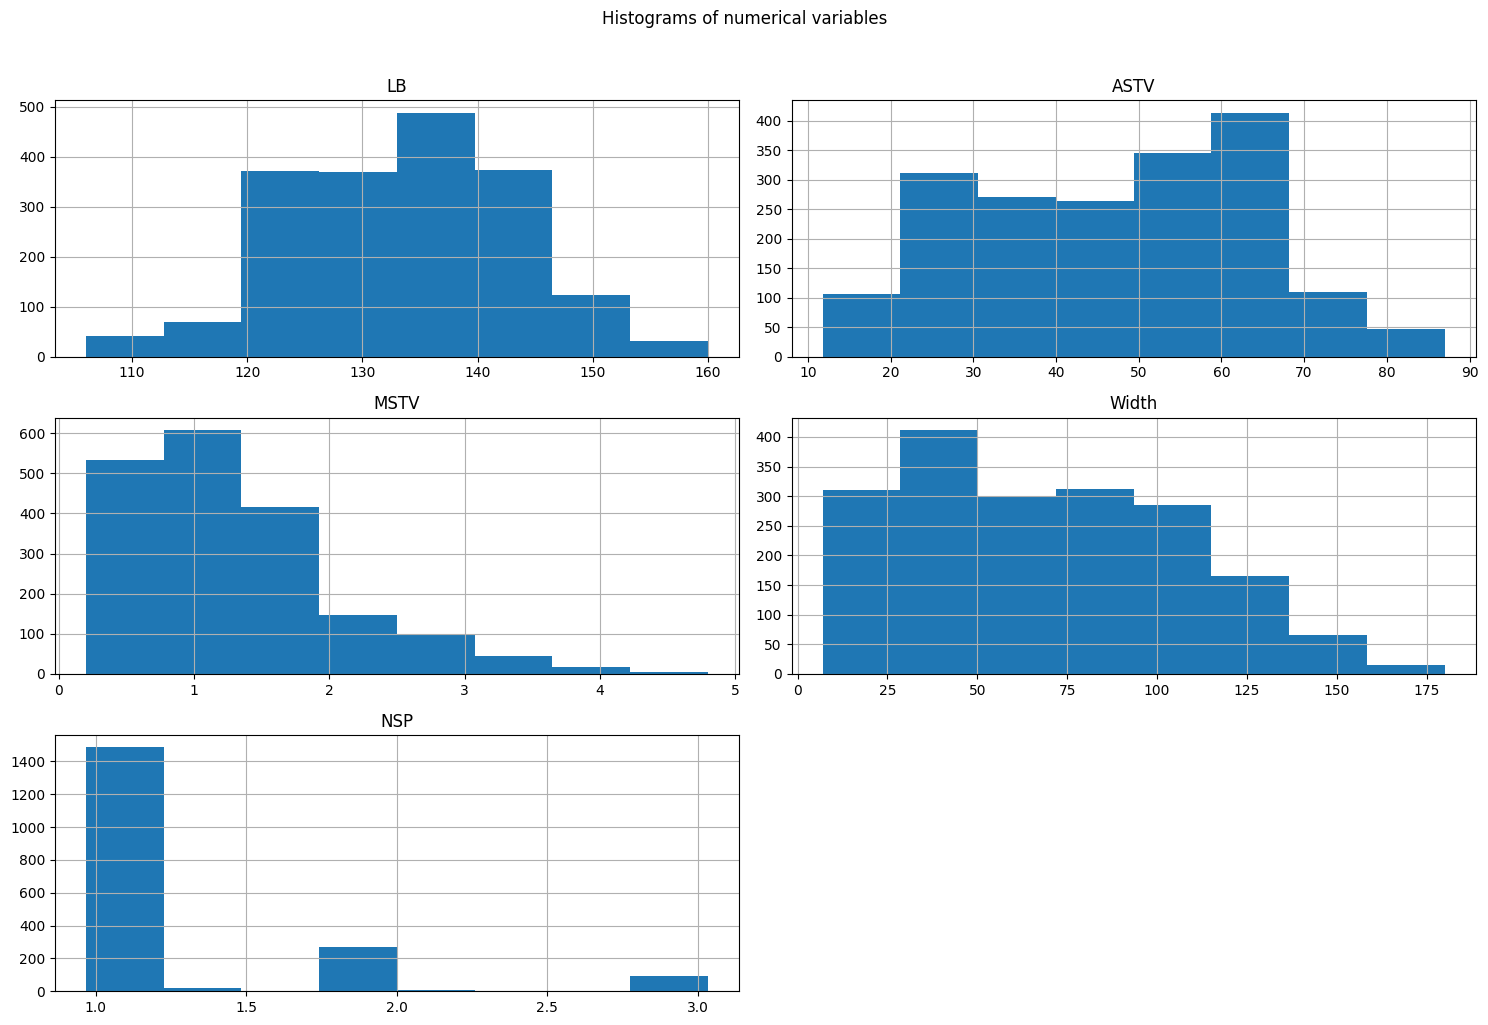

In [22]:
num_columns = ['LB','ASTV','MSTV','Width','NSP']

df[num_columns].hist(bins=8, figsize=(15, 10))
plt.suptitle('Histograms of numerical variables', y=1.02)
plt.tight_layout()
plt.show()

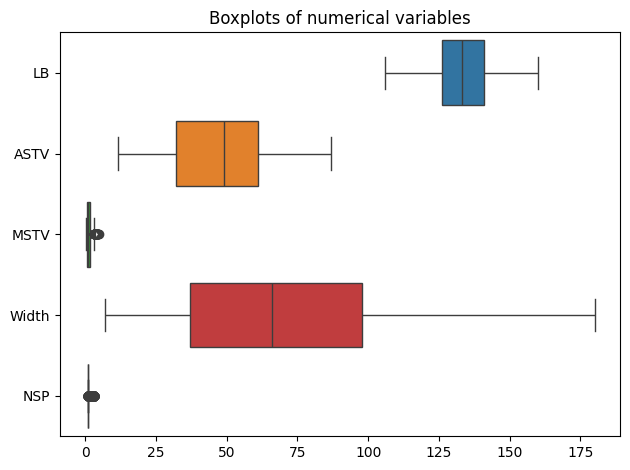

In [25]:
sns.boxplot(data=df[num_columns], orient='h')
plt.Figure(figsize=(15,10))
plt.title('Boxplots of numerical variables')
plt.tight_layout()
plt.show()

In [26]:
df['NSP'].value_counts()

NSP
1.000000    1412
2.000000     261
3.000000      86
1.304797      19
1.006826       1
            ... 
1.997472       1
3.019152       1
0.995974       1
0.992847       1
1.990464       1
Name: count, Length: 93, dtype: int64

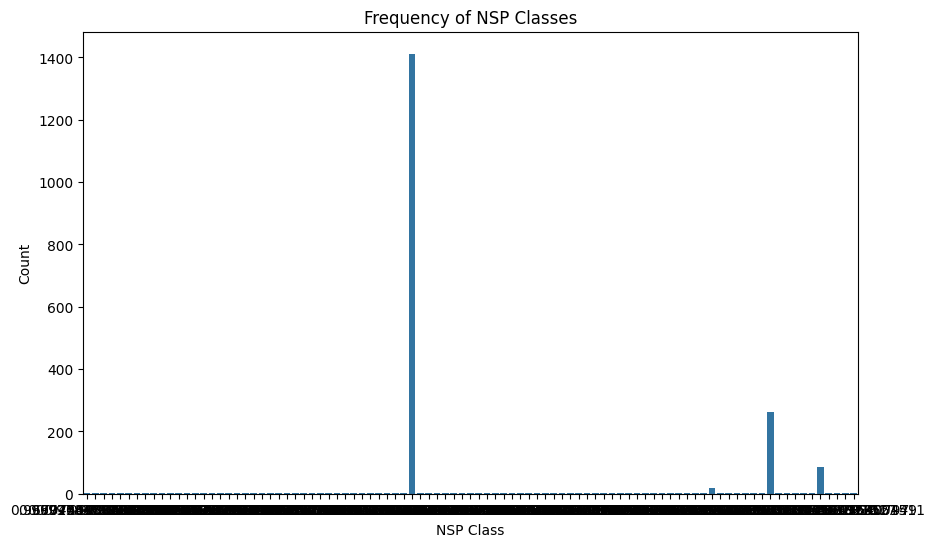

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='NSP', data=df)
plt.title('Frequency of NSP Classes')
plt.xlabel('NSP Class')
plt.ylabel('Count')
plt.show()

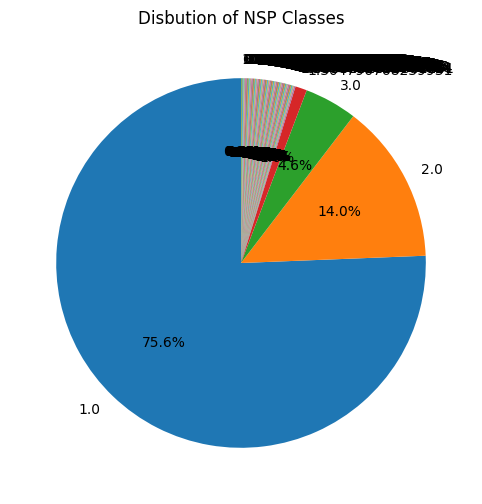

In [30]:
plt.figure(figsize=(10, 6))
df['NSP'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Disbution of NSP Classes')
plt.ylabel('')
plt.show()

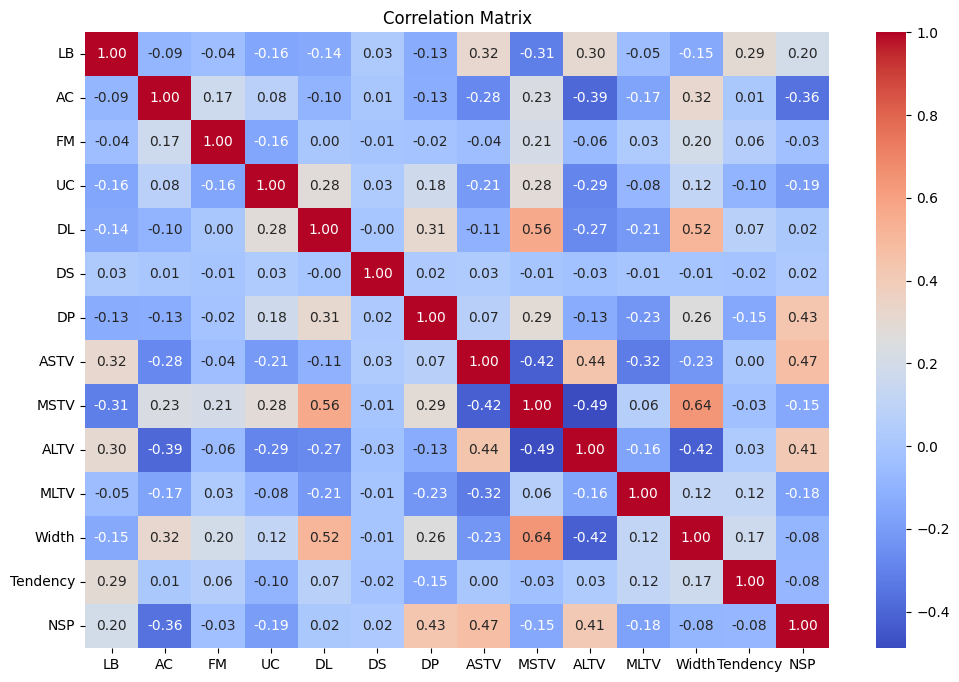

In [31]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

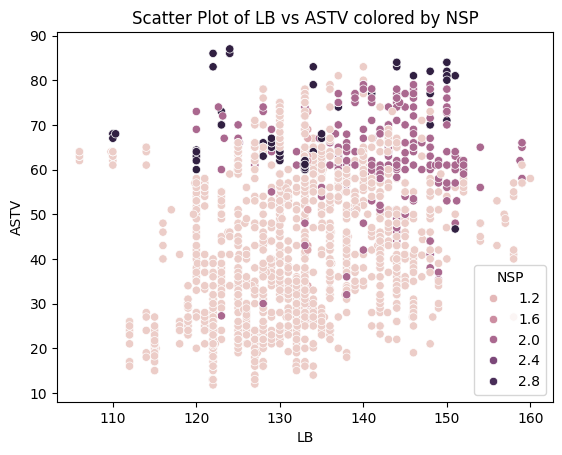

In [32]:
sns.scatterplot(x='LB', y='ASTV', hue='NSP', data=df)
plt.title('Scatter Plot of LB vs ASTV colored by NSP')
plt.xlabel('LB')
plt.ylabel('ASTV')
plt.show()

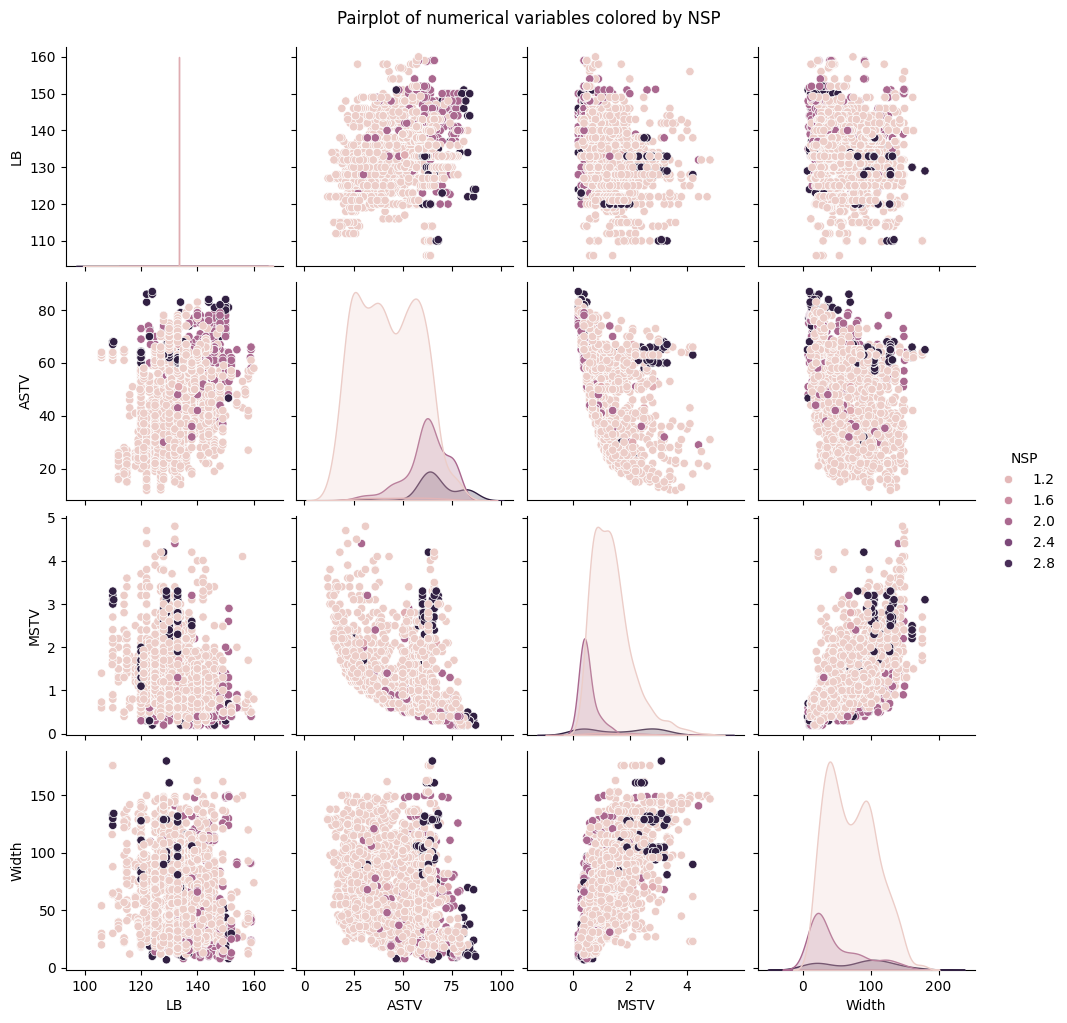

In [33]:
sns.pairplot(df[num_columns], hue='NSP', diag_kind='kde')
plt.suptitle('Pairplot of numerical variables colored by NSP', y=1.02)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.boxplot(x='NSP', y='LB', data=df)
sns.stripplot(x='NSP', y='LB', data=df, color='red', alpha=0.5)
plt.title('Boxplot of LB by NSp With Jittered Points')
sns.despine()
plt.tight_layout()
plt.show()
import scipy.stats as stats
for col in num_columns:
    plt.figure(figsize=(6, 4))
    stats.probplot(df[col], dist="norm", plot=plt)
    